# Cosmic-ray transport equation solver
## **Losses**

#### Imports

In [1]:
include("../Code/CRT_tools_3D.jl");
include("../Code/CRT_func_3D.jl");
include("../Code/losses.jl");

#### Constants

In [2]:
const pc = 3e18;
const kpc = 1e3 * pc;

#### Grid definition

In [3]:
nr, nz, np = 10, 11, 80;

r_min, r_max = pc, kpc;
z_min, z_max = pc, kpc;
p_min, p_max = 1.0, 1e6;

r_list, z_list, p_list, pu_list = make_grids(nr, nz, np, r_min, r_max, z_min, z_max, p_min, p_max);

#### Physical parameters

In [4]:
Q_0 = 1.0;
s = 4.0;
p_0 = 1e7; # p cut-off (10 TeV), MeV

r_cmz = 300 * pc;
z_cmz = 100 * pc;
V_cmz = pi * r_cmz^2 * (2 * z_cmz);

M_sol = 2e33; # Solar mass, g
m_H = 1.67e-24; # Hydrogen atom mass, g
m_avg = 1.4 * m_H; # Average hydrogen mass, g
M_cmz = 6e7 * M_sol; # CMZ mass, g

n_cmz = (M_cmz / m_avg) / V_cmz; # Particle density in the CMZ, cm^-3
println("Particle number density in the CMZ is ", n_cmz, " cm-3")
n_disk = 1.0; # Particle density in the disk, cm^-3
n_out = 1e-2; # Particle density outside the disk, cm^-3

Particle number density in the CMZ is 33.616353133287994 cm-3


#### Function for momentum losses

In [5]:
function P_dot_p(r::Float64, z::Float64, p::Float64)
    if r <= r_cmz && abs(z) <= z_cmz
        return p_p_dot(p, n_cmz)
    elseif r > r_cmz && abs(z) <= z_cmz
        return p_p_dot(p, n_disk)
    else 
        return p_p_dot(p, n_out)
    end
end

P_dot_p (generic function with 1 method)

#### Analytical solution for losses

In [6]:
function N_loss(p::Float64)
    dZ1 = 2 * z_list[length(z_list)÷2+2]
    dR1 = r_list[1]
    bin_factor = pi * dR1 * dR1 * dZ1
    return - (( (Q_0 / bin_factor) * (p_0)^s) / (1-s))  * (p^(1-s)) / P_dot_p(r_list[1], z_list[length(z_list)÷2+1], p)
end


N_sol_loss = zeros(np)

for k in eachindex(p_list)
    N_sol_loss[k] = N_loss(p_list[k])
end

#### Source term

In [7]:
function Q_loss(r::Float64, z::Float64, p::Float64, r_list::Vector{Float64}, z_list::Vector{Float64}, Q_0::Float64, p_0::Float64, s::Float64)
    if r==r_list[1] && (z==z_list[length(z_list)÷2+1] || z==z_list[length(z_list)÷2] || z==z_list[length(z_list)÷2+2]) 
        dZ1 = 2 * z_list[length(z_list)÷2+2]
        dR1 = r_list[1]
        bin_factor = pi * dR1 * dR1 * dZ1
        return (Q_0 / bin_factor) * (p / p_0)^-s
    else
        return 0
    end
end


Q_arr_loss = zeros(length(r_list), length(z_list), length(p_list)) # nr, nz, np
Qu_arr_loss = zeros(length(r_list), length(z_list), length(pu_list)) # nr, nz, np-1

for k in eachindex(p_list)
    for j in eachindex(z_list)
        for i in eachindex(r_list)
            Q_arr_loss[i, j, k] = Q_loss(r_list[i], z_list[j], p_list[k], r_list, z_list, Q_0, p_0, s) # Q(r_i, z_j, p_k)
        end
    end
end


for k in eachindex(pu_list)
    for j in eachindex(z_list)
        for i in eachindex(r_list)
            Qu_arr_loss[i, j, k] = Q_loss(r_list[i], z_list[j], pu_list[k], r_list, z_list, Q_0, p_0, s) # Q(r_i, z_i, p_k+1)
        end
    end
end

#### Time step definition

In [8]:
m = 1000
Dt_list = make_dt_list(1e9, m);

Total physical time = 1.0998937565353483e17
No. of different Dts = 97


### **Transport equation solver**

In [11]:
prev_sol = zeros(nr, nz, np)

for it in eachindex(Dt_list)

    Dt = Dt_list[it]

    A_nextp, A_np = make_Ap(r_list, z_list, p_list, P_dot_p, Dt)

    for n in 1:m

        global prev_sol

        B_np = make_Bp(A_np, prev_sol, Q_arr_loss, Qu_arr_loss, Dt)
        Threads.@threads for j in 1:nz
            @simd for i in 1:nr
                @inbounds prev_sol[i, j, :] = A_nextp[i, j] \ B_np[i, j, :]
          end
        end 
    
    end

end

#### Plot using Julia

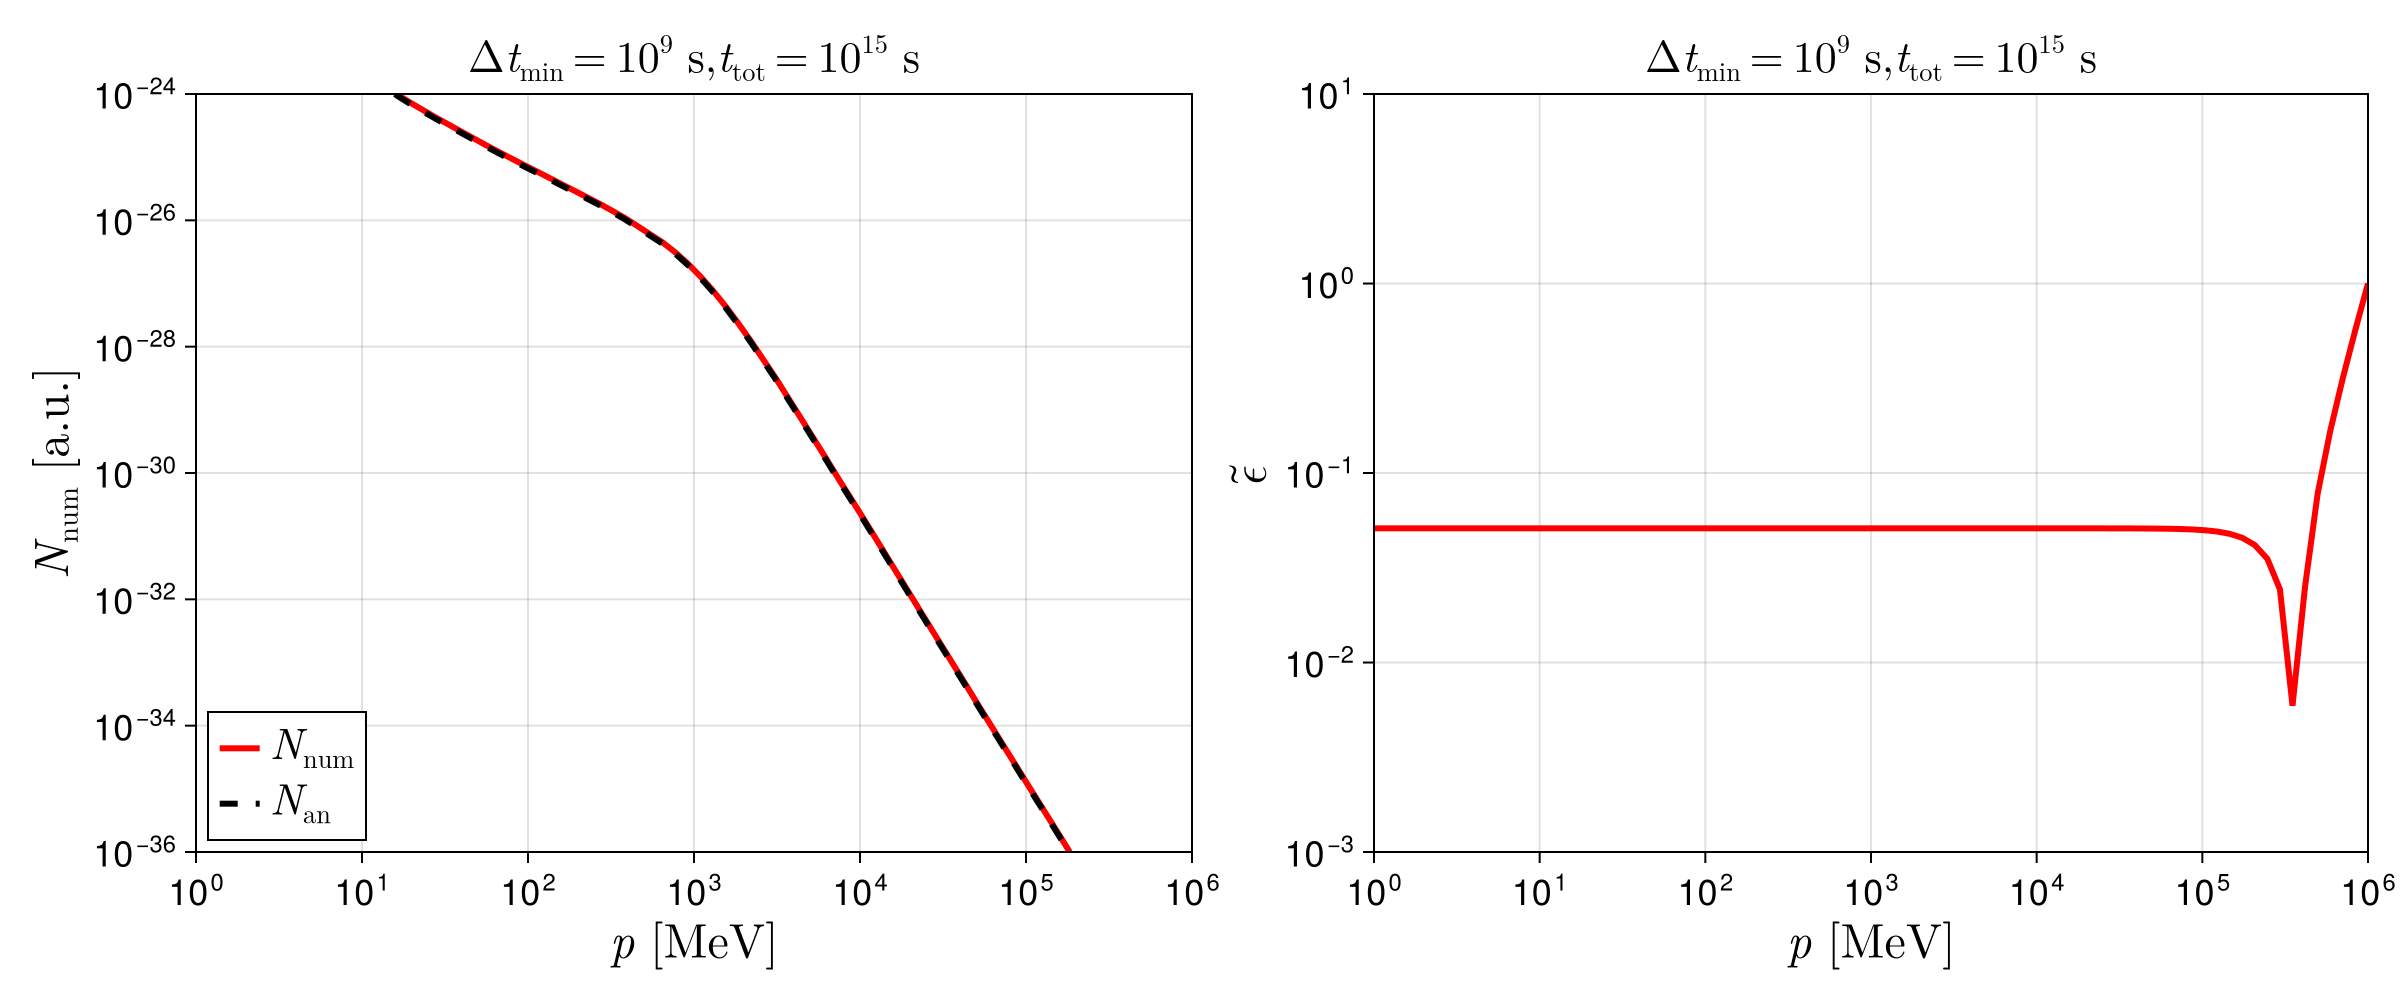

In [12]:
using CairoMakie

p = p_list

fig = Figure(size = (1200, 500), fontsize = 22)

# ---------------- LEFT: SOLUTION ----------------
ax1 = Axis(fig[1, 1],
    xlabel = L"p~[\mathrm{MeV}]",
    ylabel = L"N_{\mathrm{num}}~[\mathrm{a.u.}]",
    title = L"\Delta t_{\mathrm{min}}=10^{9}~\mathrm{s}, t_{\mathrm{tot}}=10^{15}~\mathrm{s}",
    xscale = log10,
    yscale = log10,
    limits = ((1.0, 1e6), (1e-36, 1e-24)),
    xlabelsize = 24,
    ylabelsize = 24,
    titlesize = 22,
    xticklabelsize = 18,
    yticklabelsize = 18
)

lines!(ax1, p, prev_sol[1, 5, :], color = :red, linewidth = 3, label = L"N_{\mathrm{num}}") # numerical (solid)
lines!(ax1, p, N_sol_loss, color = :black, linestyle = :dash, linewidth = 3, label = L"N_{\mathrm{an}}") # analytical (dashed)

axislegend(ax1, position = :lb, fontsize = 18)

# ---------------- RIGHT: ERROR ----------------
err = abs.(N_sol_loss .- prev_sol[1, 5, :]) ./ N_sol_loss

ax2 = Axis(fig[1, 2],
    xlabel = L"p~[\mathrm{MeV}]",
    ylabel = L"\tilde{\epsilon}",
    title = L"\Delta t_{\mathrm{min}}=10^{9}~\mathrm{s}, t_{\mathrm{tot}}=10^{15}~\mathrm{s}",
    xscale = log10,
    yscale = log10,
    limits = ((1.0, 1e6), (1e-3, 10)),

    xlabelsize = 24,
    ylabelsize = 24,
    titlesize = 22,
    xticklabelsize = 18,
    yticklabelsize = 18
)

lines!(ax2, p, err, color = :red, linewidth = 3)

fig